In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

In [149]:
#Let's first try to modelise a Discrete Hawkes process 

def DHP(kernel,gamma,theta,law,n,alpha0):
    if kernel=="Erlang":
        alpha=np.array([gamma*np.exp(-k*theta)*k for k in range(0,n)])
    if kernel=="Exponential":
        alpha=np.array([gamma*np.exp(-k*theta) for k in range(0,n)])
    
    alpha[0]=alpha0
    X_values=np.zeros(n)
    Sn=np.zeros(n)


    if law=="Bernouilli":
        X_values[0]=np.random.binomial(1,alpha[0])
        Sn[0]=X_values[0]
        for k in range(1,n):
            X_values[k]=np.random.binomial(1,alpha[0]+np.sum(alpha[k-1:0:-1]*X_values[1:k]))
            Sn[k]=Sn[k-1]+X_values[k]
    if law=="Poisson":
        X_values[0]=np.random.poisson(alpha[0])
        Sn[0]=X_values[0]
        for k in range(1,n):
            X_values[k]=np.random.poisson(alpha[0]+np.sum(alpha[k-1:0:-1]*X_values[1:k]))
            Sn[k]=Sn[k-1]+X_values[k]


    mu=alpha0/(1+alpha[0]-np.sum(alpha)) #on veut pas d'alpha0 or np.sum(alpha) l'inclut

    if law=="Bernouilli":
        sigma_asy=mu*(1-mu)/((1+alpha[0]-np.sum(alpha))**2) #same
    if law=="Poisson":
        sigma_asy=mu/((1+alpha[0]-np.sum(alpha))**2) #same

    Sn_div_n=[Sn[k]/(k+1) for k in range(0,n)]
    sigma_div=np.array([sigma_asy/np.sqrt(k+1) for k in range(0,n)])

    upper=mu + 1.96*sigma_div
    lower=mu - 1.96*sigma_div
    n_values=np.arange(1,n+1)


    plt.plot(Sn)
    plt.title(f"Discrete Hawkes process with law : {law}, kernel : {kernel}, gamma : {gamma} and theta : {theta}")
    plt.xlabel("Index")
    plt.ylabel("Valeur")
    plt.show()

    plt.plot(Sn_div_n)
    plt.title("Sn/n")
    plt.axhline(mu, color="red")
    plt.fill_between(
    n_values,
    lower,
    upper,
    color="orange",
    alpha=0.2,
    label="95% CI")

    plt.plot(n_values, upper, color="orange", alpha=0.7)
    plt.plot(n_values, lower, color="orange", alpha=0.7)
    plt.xlabel("Index")
    plt.ylabel("Valeur")
    plt.show()

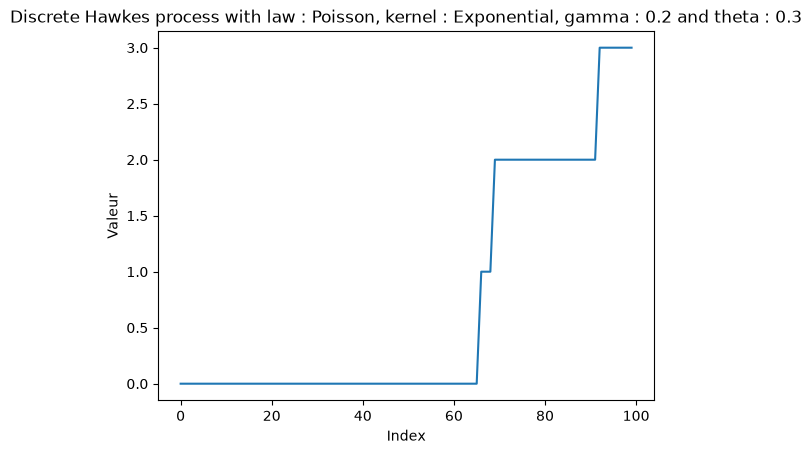

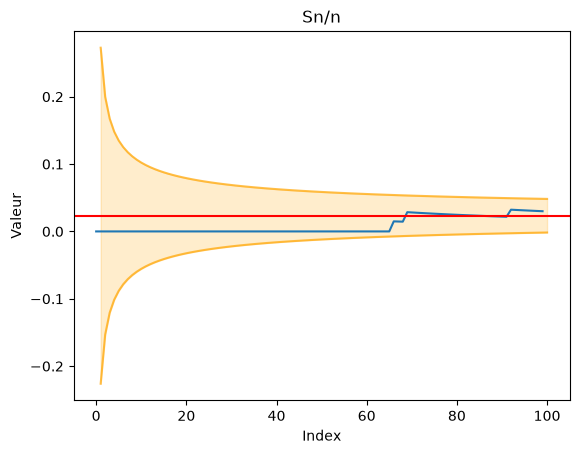

In [152]:
DHP("Exponential", 0.2, 0.3, "Poisson", 100, 0.01)

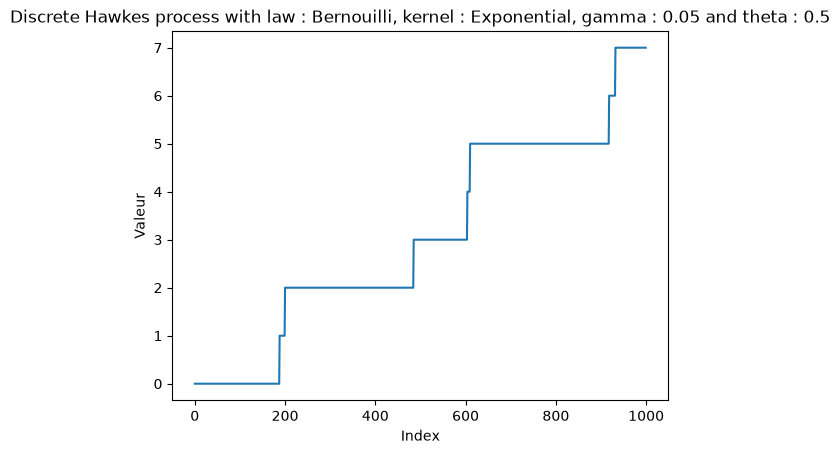

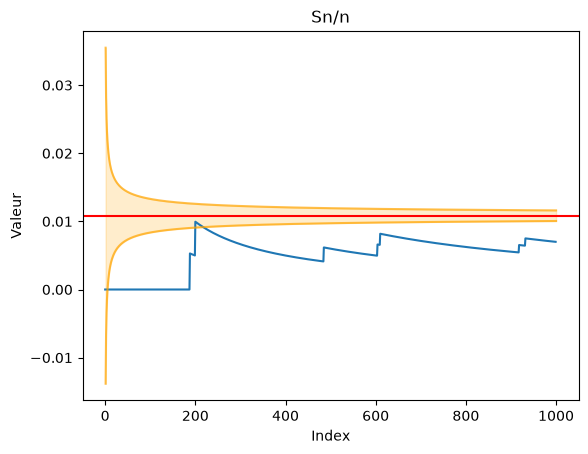

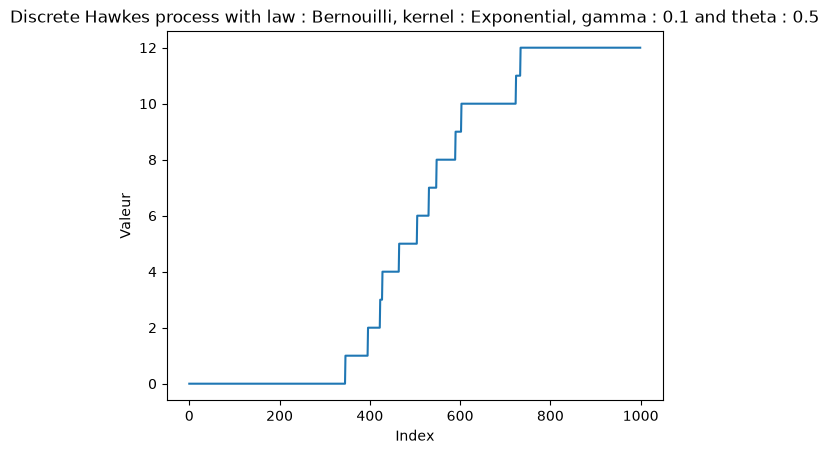

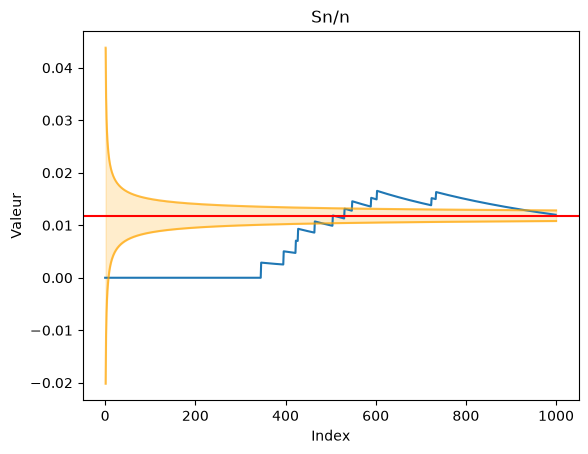

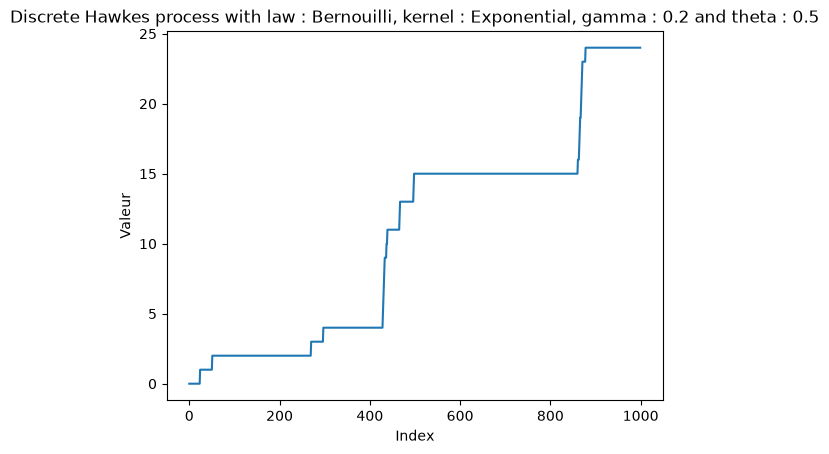

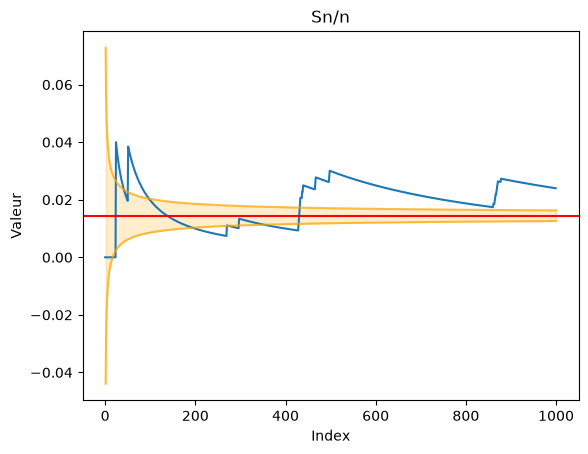

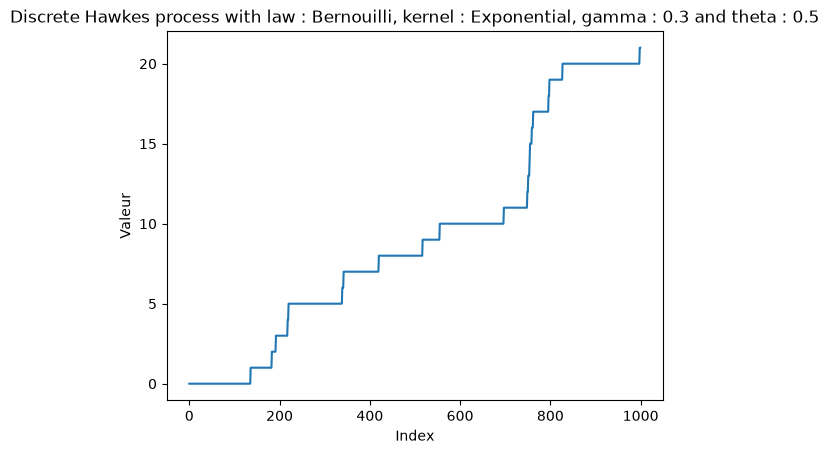

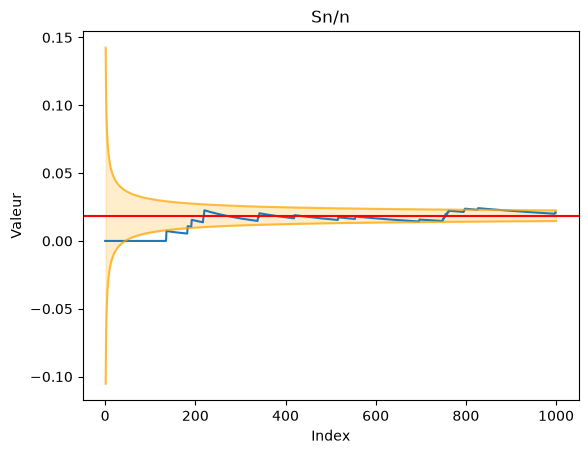

In [153]:
DHP("Exponential", 0.05, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.10, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.20, 0.5, "Bernouilli", 1000, 0.01)
DHP("Exponential", 0.30, 0.5, "Bernouilli", 1000, 0.01)


In [ ]:
#Let's try to code a continuous Hawkes Process
# First let's try to just inverse the distribution function
#Then we will use the Thinning d'Ogatta


#We can define it so easily and recursively just because we have an exponential kernel, which allows to just multiply each time
#For calculation, I'll add a note on how we came to such an easy loop !


def CHP(alpha0,beta,gamma,T_max):

    if gamma/beta>=1:
        raise ValueError("Attention, il est nécessaire d'avoir : γ/β < 1 afin d'assurer la condition sur la fonction d'excitation")

    #alpha 0 : intensité de fond (baseline)
    #gamma : amplitude du noyau d'excitation
    #beta : taux de décroissance

    T=0,
    phi=0

    N=[0]

    while T<T_max:
        u=np.random.uniform(0,1)
        S = lambda delta: 1 -(np.exp(-alpha0*delta - phi*(1-np.exp(-beta*delta))/beta)) #Fonction de répartition de Δn+1 appliqué en δ (on part de la fonction de survie)

        b = -np.log(1 - u) / alpha0   # borne haute garantie (car S(b) >= 1-e^{-alpha0*b} = u)
        G_delta = brentq(lambda x: S(x) - u, 0, 100) #G_delta est une simulation de la variable aléatoire Δn+1 

        T=T+ G_delta #Tn+1 = Tn + Δn+1   (ici G_delta car on utilise une simulation)

        phi=phi*np.exp(-beta*G_delta) + gamma #Φn+1 = Φn * exp(-β * Δn+1) + γ

        N.append(T) #On incrémente N du temps du nouvel évènement : N est totalement encodé par (T1,...,Tn)
    N = N[:-1]

    ordonne=np.array(len(N))
    plt.step(N,ordonne,where='post')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Fonction en escalier (comptage cumulatif)')
    plt.grid(True, alpha=0.3)
    plt.show()




In [6]:
alpha0 = 1.0    # intensité de fond
gamma  = 0.8    # amplitude du noyau
beta   = 1.0    # taux de décroissance
T_max  = 50.0   # horizon

CHP(alpha0,beta,gamma,T_max)

TypeError: '<' not supported between instances of 'tuple' and 'float'